In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib widget
from scipy.signal import welch, detrend, csd, coherence, find_peaks
from scipy.linalg import svd

plt.rcParams['font.sans-serif'] = 'STIXGeneral'
plt.rcParams['figure.figsize'] = (5, 4.5)
plt.rcParams['figure.dpi'] = 80
plt.rcParams.update({'font.size': 12}) 

In [2]:
import os

carpeta_data = 'storage/emulated/0/Data_ITATA'

In [3]:
data_all = [archivo for archivo in os.listdir(f'/{carpeta_data}/') if archivo.endswith(".txt")]
for i in range(len(data_all)):
    print('[{}]'.format(i),'-->', data_all[i])

[0] --> Proc_Excitacion_20260507_112825.txt
[1] --> Proc_Excitacion_20260507_124913.txt
[2] --> Proc_Excitacion_20260507_165408.txt
[3] --> Proc_Excitacion_20260508_034629.txt
[4] --> Proc_Excitacion_20260508_132702.txt
[5] --> Proc_Excitacion_20260508_154628.txt
[6] --> Proc_Excitacion_20260508_160632.txt
[7] --> Proc_Excitacion_20260509_074822.txt
[8] --> Proc_Excitacion_20260509_115942.txt
[9] --> Proc_Excitacion_20260509_135438.txt
[10] --> Proc_Excitacion_20260509_175409.txt
[11] --> Proc_Excitacion_20260509_195552.txt
[12] --> Proc_Excitacion_20260510_061349.txt
[13] --> Proc_Excitacion_20260511_105419.txt
[14] --> Proc_Excitacion_20260512_213724.txt
[15] --> Proc_Excitacion_20260514_064814.txt
[16] --> Proc_Reposo_20260507_124913.txt
[17] --> Proc_Reposo_20260508_154628.txt
[18] --> Proc_Reposo_20260509_074822.txt
[19] --> Proc_Reposo_20260509_195552.txt
[20] --> Proc_Reposo_20260510_061349.txt
[21] --> Proc_Reposo_20260511_105419.txt
[22] --> Proc_Reposo_20260512_213724.txt
[23

In [4]:
for i in range(23,40): #range(len(data_all))
    df = pd.read_table(f'/{carpeta_data}/{data_all[i]}', decimal=".")
    t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds() # Tiempo total
    N = len(df) # Cantidad de muestras 
    fs = N / t_total # Frecuencia de muestreo
    #print(f'Cantidad de datos:\t{N}')
    print(f'{data_all[i]}:\t{N} datos\tfs: {fs:.4f} Hz')

Proc_Sismo_20260509_223448.txt:	23031 datos	fs: 250.3370 Hz
Proc_Tren_20260502_092150.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260502_161609.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260504_113353.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260504_142017.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260504_164914.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260504_190842.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_042815.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_095032.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_113710.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_141516.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_161238.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_164918.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260505_191956.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260506_053130.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260506_134319.txt:	25001 datos	fs: 250.0100 Hz
Proc_Tren_20260506_155242.txt:	25001 datos	fs: 250.0100

In [5]:
def plot_all_accel_rms(df, fs, ventana_rms, name_data, COND):
    
    # Detectar sensores automáticamente desde columnas tipo Ac00_L
    cols_accel = [c for c in df.columns if c != "Time"]
    sensores = sorted(list(set(c.split("_")[0] for c in cols_accel)))
    direcciones = ["L", "T", "V"]

    n = len(df)
    t = np.arange(n) / fs

    n_rms = int(ventana_rms * fs)
    kernel = np.ones(n_rms) / n_rms

    fig, axes = plt.subplots(nrows=len(sensores),ncols=len(direcciones),figsize=(15, 2.4 * len(sensores)),sharex=True)

    if len(sensores) == 1:
        axes = np.array([axes])

    for i, sensor in enumerate(sensores):
        for j, direccion in enumerate(direcciones):

            ax = axes[i, j]
            col = f"{sensor}_{direccion}"

            if col not in df.columns:
                ax.set_visible(False)
                continue

            accel = df[col].to_numpy(dtype=float)

            rms = np.sqrt(np.convolve(accel**2, kernel, mode="valid"))
            t_rms = t[n_rms//2 : n_rms//2 + len(rms)]

            ax.plot(t, accel, color='tab:blue' ,linewidth=0.5, alpha=1, label="Aceleración")
            ax.plot(t_rms, rms, color='red' , linewidth=1.5, label=f"RMS {ventana_rms}s")

            ax.set_title(col, fontsize=10, fontweight="bold")
            ax.grid(True, alpha=0.25)
            ax.minorticks_on()
            ax.grid(which="minor", alpha=0.08)
            
            #ax.set_ylim(-1.5, 1.5)

            if j == 0:
                ax.set_ylabel("Acel. [g]")

            if i == len(sensores) - 1:
                ax.set_xlabel("Tiempo [s]")

            ax.legend(fontsize=7, loc="upper right", frameon=False)

    fig.suptitle(f"{name_data}\nAceleración + RMS móvil",fontsize=15,fontweight="bold")

    plt.tight_layout()
    if COND == True:
        plt.savefig(f"DATA_PuenteItata/Figures_ACCEL_ALL/PUENTE_ITATA_ACCEL_{name_data}.jpg", dpi=800)
    plt.show()

In [6]:
# for i in [0]: #idx_buenos range(len(data_all))
#     data = data_all[i]
#     name_data = data[:-4]
#     print(f'Registro escogido: {data}')
#     print(f'Nombre data: {name_data}')
#     df = pd.read_table(f'/{carpeta_data}/{data}', decimal=".")
#     plot_all_accel_rms(df,fs=fs,ventana_rms=5,name_data=name_data, COND=False)

In [7]:
def FDD(df,canales,fs,nperseg,name_data,COND):
    # ============================================================
    # 1) DEFINICIÓN DE PARÁMETROS GENERALES
    # ============================================================

    # ============================================================
    # 2) CONFIGURACIÓN DE WELCH / CSD
    # ============================================================

    # Para registros largos, usar ventanas largas mejora la resolución frecuencial
    # df_frec = fs / nperseg

    noverlap = nperseg // 2
    # print("\nParámetros espectrales:")
    # print("nperseg:", nperseg)
    # print("noverlap:", noverlap)
    # print("Resolución frecuencial aproximada [Hz]:", fs/nperseg)

    # ============================================================
    # 3) PSD PARA TODOS LOS CANALES
    # ============================================================

    psd = {}
    for col in canales:

        f, Pxx = welch(
            df[col].values,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density"
        )

        psd[col] = Pxx


    # ============================================================
    # 4) GRÁFICO PSD - TODOS LOS CANALES
    # ============================================================

    # plt.figure(figsize=(10, 4.5), dpi=100)

    # for col in canales:
    #     plt.semilogy(f, psd[col], alpha=1, linewidth=1, label=col)

    # plt.xlim(0, 30)
    # plt.xlabel("Frecuencia [Hz]", fontsize=12)
    # plt.ylabel("PSD [g²/Hz]", fontsize=12)
    # plt.title(f'{name_data}\nDensidad espectral de potencia - todos los canales', fontsize=14, fontweight='bold')
    # plt.grid(which="major", alpha=0.15)
    # plt.minorticks_on()
    # plt.grid(which="minor", alpha=0.05)
    # plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
    # plt.tight_layout()
    # plt.show()


    # ============================================================
    # 5) FDD - MATRIZ ESPECTRAL MULTICANAL
    # ============================================================

    n_canales = len(canales)
    n_freq = len(f)

    # Matriz espectral:
    # Gyy[k, i, j] corresponde a la CSD entre canal i y canal j
    # para la frecuencia f[k]
    Gyy = np.zeros((n_freq, n_canales, n_canales), dtype=complex)

    for i, col_i in enumerate(canales):
        for j, col_j in enumerate(canales):

            f_csd, Pij = csd(
                df[col_i].values,
                df[col_j].values,
                fs=fs,
                window="hann",
                nperseg=nperseg,
                noverlap=noverlap,
                detrend="constant",
                scaling="density"
            )

            Gyy[:, i, j] = Pij


    # ============================================================
    # 6) SVD DE LA MATRIZ ESPECTRAL
    # ============================================================

    # Valores singulares para cada frecuencia
    S_valores = np.zeros((n_freq, n_canales))

    # Vectores singulares izquierdos
    # Estos pueden usarse después como estimación de formas modales
    U_vectores = np.zeros((n_freq, n_canales, n_canales), dtype=complex)

    for k in range(n_freq):

        U, S, VH = svd(Gyy[k, :, :])

        S_valores[k, :] = S
        U_vectores[k, :, :] = U


    # ============================================================
    # 7) GRÁFICO FDD - VALORES SINGULARES
    # ============================================================

    # plt.figure(figsize=(10, 4.5), dpi=100)

    # # Cantidad de valores singulares a graficar
    # # Para no saturar el gráfico, normalmente basta con 4 a 6
    # n_sv_plot = min(4, n_canales)

    # for i in range(n_sv_plot):
    #     plt.semilogy(f, S_valores[:, i], linewidth=1, label=f"SV{i+1}")

    # plt.xlim(0, 30)
    # plt.xlabel("Frecuencia [Hz]", fontsize=12)
    # plt.ylabel("Valores singulares", fontsize=12)
    # plt.title(f'{name_data}\nFDD - valores singulares de la matriz espectral', fontsize=14, fontweight='bold')
    # plt.grid(which="major", alpha=0.15)
    # plt.minorticks_on()
    # plt.grid(which="minor", alpha=0.05)
    # plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
    # plt.tight_layout()
    # plt.show()


    # ============================================================
    # 8) OPCIONAL - IDENTIFICAR FRECUENCIAS CANDIDATAS DESDE SV1
    # ============================================================

    from scipy.signal import find_peaks

    SV1 = S_valores[:, 0]

    # Se buscan peaks en SV1.
    # prominence controla qué tan dominante debe ser un peak.
    peaks, props = find_peaks(SV1,prominence=np.max(SV1) * 0.00001,distance=1)

    freq_peaks = f[peaks]
    sv1_peaks = SV1[peaks]

    # Filtrar solo hasta 30 Hz
    mask = freq_peaks <= 30

    freq_peaks = freq_peaks[mask]
    sv1_peaks = sv1_peaks[mask]

    # print("\nFrecuencias candidatas FDD desde SV1:")
    # for fp, amp in zip(freq_peaks, sv1_peaks):
    #     print(f"{fp:.3f} Hz   |   SV1 = {amp:.4e}")


    # ============================================================
    # 9) GRÁFICO FDD CON PEAKS IDENTIFICADOS
    # ============================================================

    # plt.figure(figsize=(10, 4.5), dpi=100)

    # plt.semilogy(f, SV1, color='tab:blue' ,linewidth=1, label="SV1")
    # #plt.semilogy(freq_peaks, sv1_peaks, "o", label="Peaks candidatos")

    # plt.semilogy(freq_peaks, sv1_peaks,"o",markerfacecolor="none",markeredgecolor="red",markeredgewidth=1.5,label="Peaks candidatos")

    # for fp, amp in zip(freq_peaks, sv1_peaks):
    #     plt.text(fp, amp, f" {fp:.2f} Hz", fontsize=8, rotation=15)
    #     #plt.axvline(fp, color='gray', linestyle='--', linewidth=0.5, alpha=1)

    # plt.xlim(0, 30)
    # plt.margins(y=0.1)
    # plt.xlabel("Frecuencia [Hz]", fontsize=12)
    # plt.ylabel("Valor singular SV1", fontsize=12)
    # plt.title(f'{name_data}\nFDD - identificación preliminar de frecuencias candidatas', fontsize=14, fontweight='bold')
    # plt.grid(which="major", alpha=0.15)
    # plt.minorticks_on()
    # plt.grid(which="minor", alpha=0.05)
    # plt.legend(loc=4, fontsize=9, ncol=1, frameon=True)
    # plt.tight_layout()
    # if COND == True:
    #     plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_{name_data}.jpg", dpi=800)
    # plt.show()
    
    return f, SV1, Gyy, S_valores, U_vectores, freq_peaks, sv1_peaks

In [8]:
f_all = []
SV1_all = []
U_vectores = []

fs = 250 #frecuencia de muestreo [Hz]
nperseg = 2048*2 #4086 - 40960 #resolución frecuencial
direccion = 'ALL'

for i in range(23,40): #idx_buenos range(len(data_all))
    df = pd.read_table(f'/{carpeta_data}/{data_all[i]}', decimal=".")
    t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds() # Tiempo total
    N = len(df) # Cantidad de muestras 
    fs = N / t_total # Frecuencia de muestreo
    if direccion == 'ALL': canales = list(df.columns[1:])
    else: canales = [f'Ac00_{direccion}', f'Ac01_{direccion}', f'Ac02_{direccion}', f'Ac03_{direccion}', f'Ac05_{direccion}']
    case = FDD(df, canales, fs, nperseg, data_all[i][:-4], False)
    f_all.append(case[0])
    SV1_all.append(case[1])
    U_vectores.append(case[4])

In [9]:
if direccion == 'L': name_direc = 'Longitudinal'
elif direccion == 'T': name_direc = 'Transversal'
elif direccion == 'V': name_direc = 'Vertical'
elif direccion == 'ALL': name_direc = 'Multidireccional' #Multidireccional

In [10]:
if direccion == 'L': name_direc = 'Longitudinal'
elif direccion == 'T': name_direc = 'Transversal'
elif direccion == 'V': name_direc = 'Vertical'
elif direccion == 'ALL': name_direc = 'Multidireccional' #Multidireccional

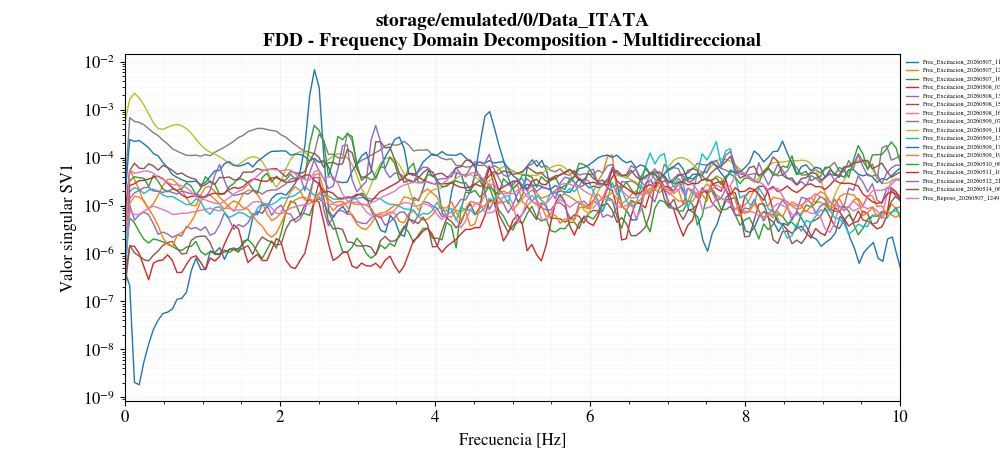

In [11]:
plt.figure(figsize=(10, 4.5), dpi=100)
# plt.axvline(2.44, color='k', linestyle='--', linewidth=1)
# plt.axvline(4.70, color='k', linestyle='--', linewidth=1)
# plt.axvline(6.16, color='k', linestyle='--', linewidth=1)
for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], linewidth=1, label=f"{data_all[i][:-4]}")
plt.xlim(0, 10)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f'{carpeta_data}\nFDD - Frequency Domain Decomposition - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=2, fontsize=4.5, ncol=1, frameon=False, bbox_to_anchor=(1,1))
#plt.tight_layout()

#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_ALL_ACOT.jpg", dpi=800)
plt.show()

In [12]:
f_all_np = np.array(f_all)
SV1_all_np = np.array(SV1_all)

# SV1_all_mean = np.mean(SV1_all_np, axis=0)
# SV1_all_min = np.min(SV1_all_np, axis=0)
# SV1_all_max = np.max(SV1_all_np, axis=0)

perc = 95
SV_per = np.percentile(SV1_all_np, perc, axis=0)
f_per = np.percentile(f_all_np, 100, axis=0)

peaks, props = find_peaks(SV_per,prominence=np.max(SV_per)*0.0000001,distance=1)
freq_peaks = f_per[peaks]; sv1_peaks = SV_per[peaks]
# Filtrar solo hasta 30 Hz
mask = freq_peaks <= 30
freq_peaks = freq_peaks[mask]
sv1_peaks = sv1_peaks[mask]

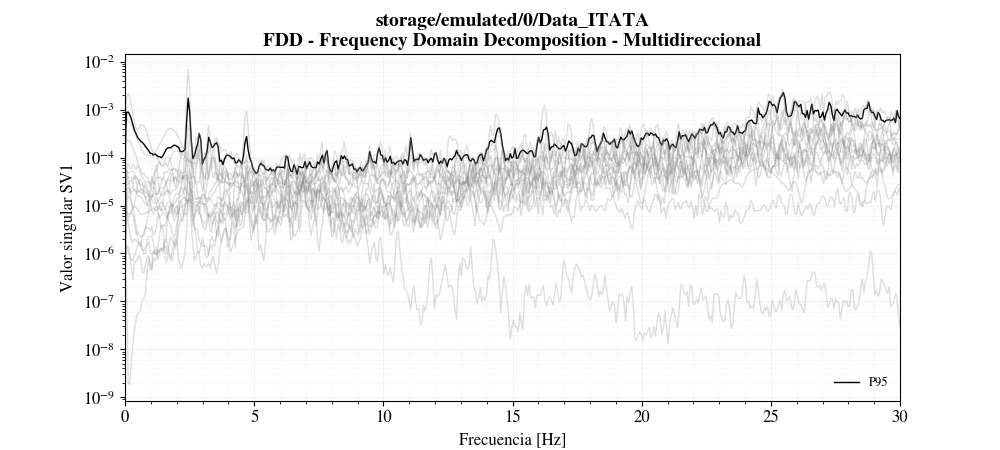

In [13]:
plt.figure(figsize=(10, 4.5), dpi=100)
plt.semilogy(f_per, SV_per, color='k', alpha=1, linewidth=1, label=f"P{perc}")
    #plt.axvline(fp, color='gray', linestyle='--', linewidth=0.5, alpha=1)
#plt.semilogy(f_mean, SV1_all_mean, color='blue', alpha=1, linewidth=1, label="PROM")
#plt.semilogy(f_min, SV1_all_min, color='lime', alpha=1, linewidth=1, label="MAX")
for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], color='gray', alpha=0.25, linewidth=1)
plt.xlim(0, 30)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f'{carpeta_data}\nFDD - Frequency Domain Decomposition - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
#plt.tight_layout()

#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_ALL_P95.jpg", dpi=800)
plt.show()

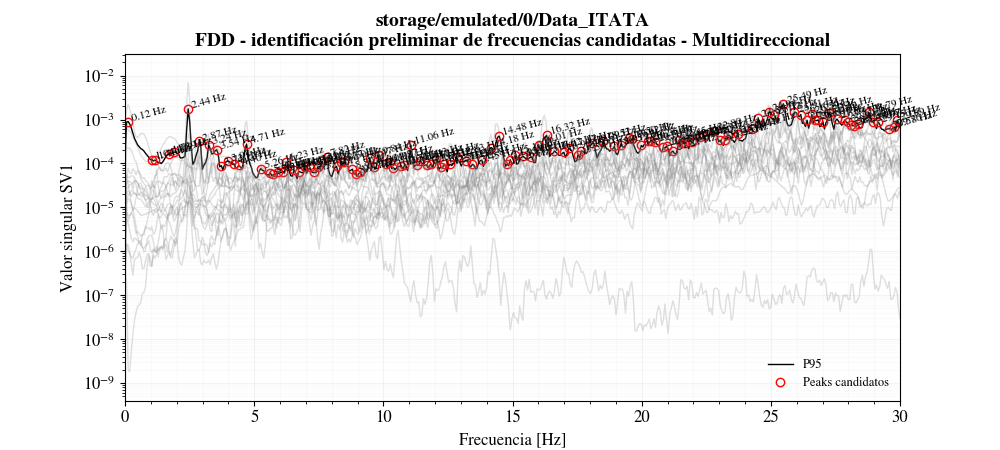

In [14]:
plt.figure(figsize=(10, 4.5), dpi=100)
plt.semilogy(f_per, SV_per, color='k', alpha=1, linewidth=1, label=f"P{perc}")
plt.semilogy(freq_peaks, sv1_peaks,"o",markerfacecolor="none",markeredgecolor="red",markeredgewidth=1,label="Peaks candidatos")
for fp, amp in zip(freq_peaks, sv1_peaks):
    plt.text(fp, amp, f" {fp:.2f} Hz", fontsize=8, rotation=15)
    #plt.axvline(fp, color='gray', linestyle='--', linewidth=0.5, alpha=1)
#plt.semilogy(f_mean, SV1_all_mean, color='blue', alpha=1, linewidth=1, label="PROM")
#plt.semilogy(f_min, SV1_all_min, color='lime', alpha=1, linewidth=1, label="MAX")
for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], color='gray', alpha=0.25, linewidth=1)
plt.xlim(0, 30)
plt.margins(y=0.1)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f'{carpeta_data}\nFDD - identificación preliminar de frecuencias candidatas - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
#plt.tight_layout()

#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_ALL_P95_ACOT.jpg", dpi=800)
plt.show()